In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv("Bengaluru_House_Data.csv")

In [7]:
print(df.shape)
df.head()
df.info()
df.describe()

(13320, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [8]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [9]:
df = df.drop(
    ['area_type',
     'availability',
     'society'],
    axis=1
)

In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [12]:
def get_bhk(size):
    return int(size.split(' ')[0])
df['bhk'] = df['size'].apply(get_bhk)
df[['size','bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [13]:
def convert_sqft(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        return (
            float(tokens[0]) +
            float(tokens[1])
        ) / 2
    try:
        return float(x)
    except:
        return np.nan

In [14]:
df['total_sqft'] = (
    df['total_sqft']
    .apply(convert_sqft)
)
df = df.dropna()
df['total_sqft'].dtype

dtype('float64')

In [15]:
df['price_per_sqft'] = (
    df['price'] * 100000
) / df['total_sqft']

In [16]:
location_avg_price = (
    df.groupby('location')['price']
    .mean()
)

In [17]:
location_avg_price.head()

,price
location,
Anekal,16.000000
Banaswadi,35.000000
Basavangudi,50.000000
Bhoganhalli,22.890000
Devarabeesana Halli,124.833333


In [18]:
city_avg_price = (df['price'].mean())

In [19]:
df['location_avg_price'] = (df['location'].map(location_avg_price))

In [20]:
df['location_premium'] = (df['location_avg_price']/city_avg_price)

In [21]:
df['sqft_per_bhk'] = (df['total_sqft'] / df['bhk'])

In [22]:
# Remove outliers
df = df[df['sqft_per_bhk'] >= 300]

In [23]:
df = df[df['bath'] < df['bhk'] + 3]

In [24]:
location_count = (
    df.location
    .value_counts()
)

In [25]:
location_count = (
    df.location
    .value_counts()
)

In [26]:
df.location = (
    df.location.apply(
        lambda x:
        'other'
        if location_count[x] <= 10
        else x
    )
)

In [27]:
df = df.drop(
    ['size'],
    axis=1
)

In [28]:
df.to_csv(
    "cleaned_house_data.csv",
    index=False
)

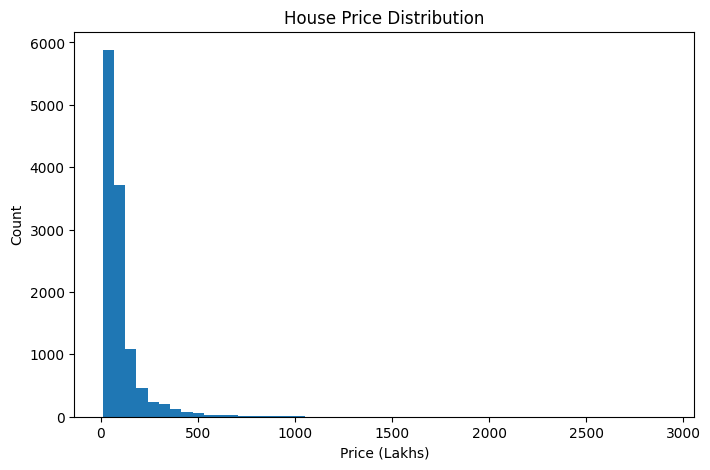

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50)
plt.title("House Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Count")
plt.show()

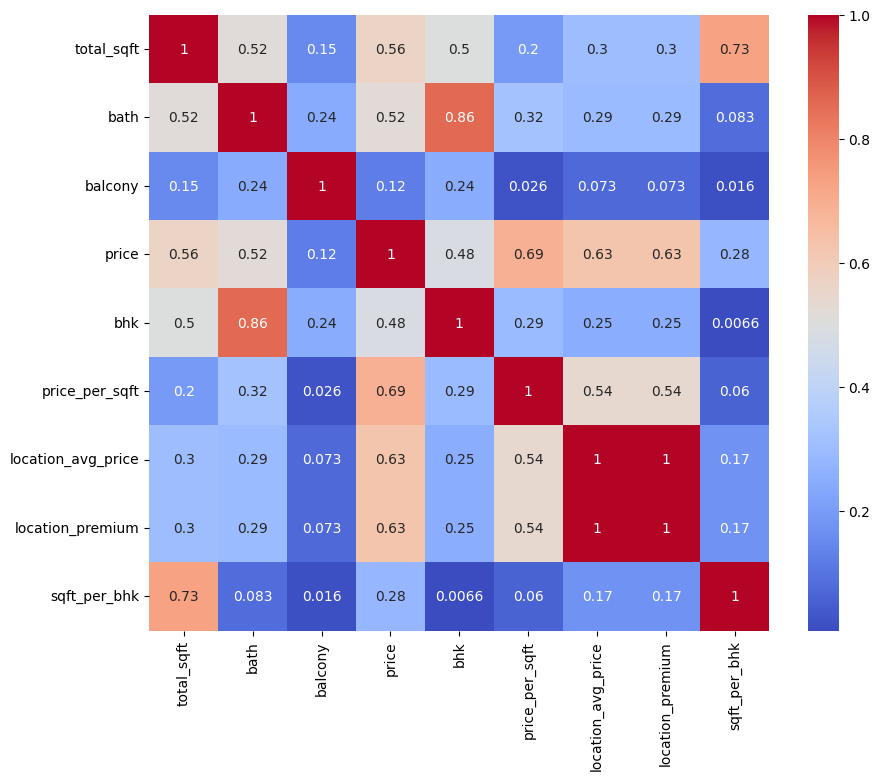

In [30]:
import seaborn as sns
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

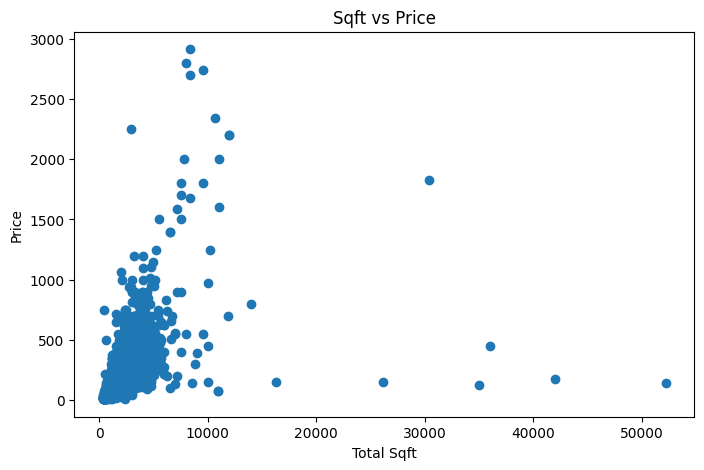

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['total_sqft'],
    df['price']
)

plt.xlabel("Total Sqft")
plt.ylabel("Price")

plt.title("Sqft vs Price")

plt.show()

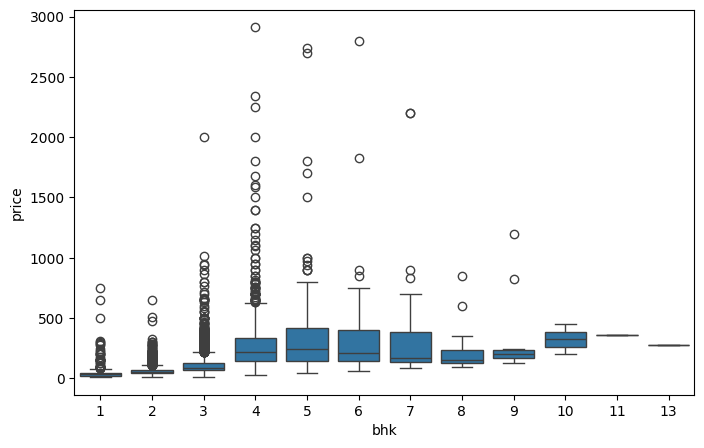

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['bhk'],
    y=df['price']
)

plt.show()

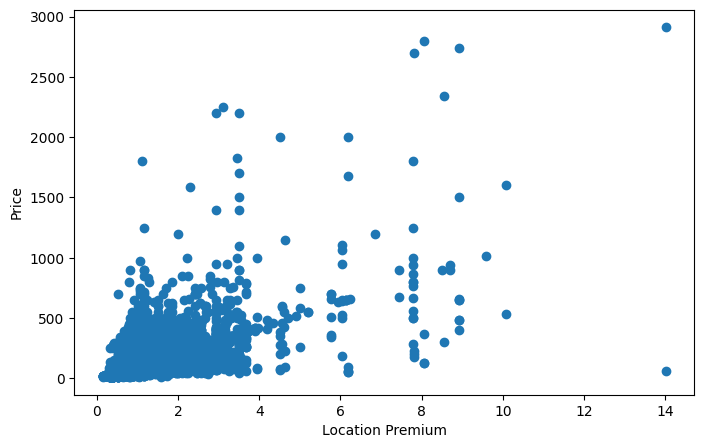

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['location_premium'],
    df['price']
)
plt.xlabel("Location Premium")
plt.ylabel("Price")

plt.show()

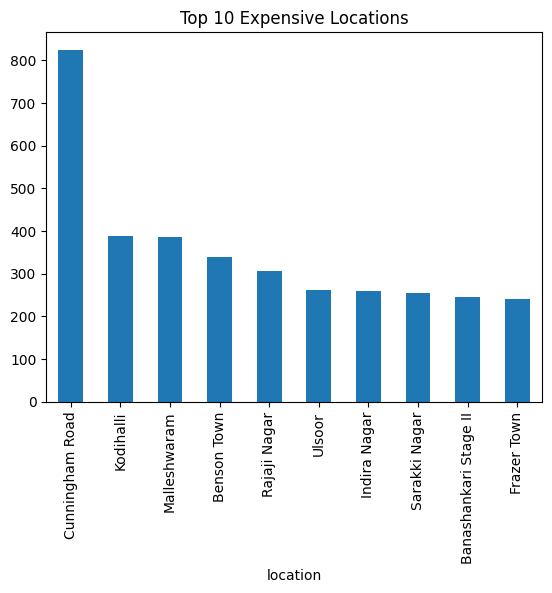

In [34]:
top_locations = (
df.groupby('location')['price']
.mean()
.sort_values(ascending=False)

)
top_locations.head(10).plot(
    kind='bar'
)

plt.title(
    "Top 10 Expensive Locations"
)

plt.show()

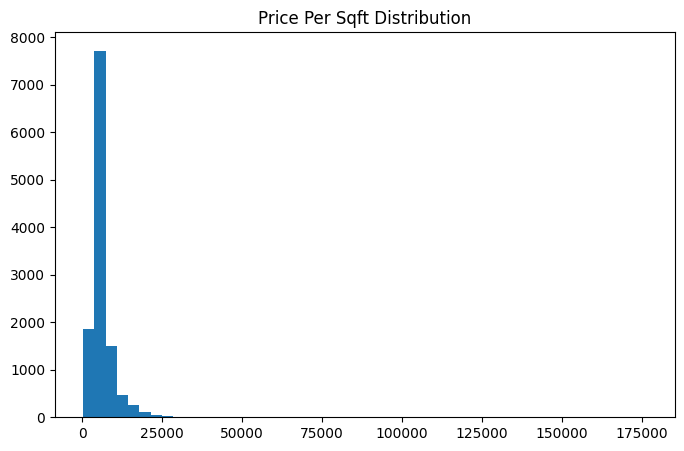

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    df['price_per_sqft'],
    bins=50
)

plt.title(
    "Price Per Sqft Distribution"
)

plt.show()

In [36]:
df['market_gap'] = (

df['price']

-

df['location_avg_price']

)
df[
[
'price',
'location_avg_price',
'market_gap'
]
].head()

,price,location_avg_price,market_gap
0,39.07,45.771538,-6.701538
1,120.00,118.662143,1.337857
2,62.00,61.252527,0.747473
3,95.00,115.348261,-20.348261
4,51.00,91.213559,-40.213559


In [37]:
df.to_csv(
    "house_data_for_model.csv",
    index=False
)